In [3]:
import logging
from typing import Callable, Tuple
import numpy

logger = logging.getLogger("TEV")
logging.basicConfig(
    format="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
    filename="output/count_gates.log",
    encoding="utf-8",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.getLogger("crsq").setLevel(logging.INFO)

from crsq.blocks import (
    wave_function,
    hamiltonian,
    discretization,
    rfqhamiltonian,
    hamiltonian2,
    energy_initialization,
    antisymmetrization,
)
from crsq.models import hydrogen1d, hydrogen2d, hydrogen3d

from crsq.utils import circuit_tools as ctools

from qiskit import QuantumCircuit


def rfunc_for_rfq(r):
    return r


# def count_gate_rfq(dim, n):
#     dq = 1 / 2 ** (n - 1)
#     tb = radial_func_qrom.RadialFuncQrom(n, dq, rfunc_for_rfq, verbose=False)
#     qc = ctools.decompose_circuit_to_privmities(tb.circuit)
#     ops = qc.count_ops()
#     ops2 = ctools.merge_controled_gates(ops)
#     print(f"n:{n}  rfq count_ops:{ops2}")
#     return qc


# count_gates_and_save_as_csv(5, 8, count_gate_rfq, "rfqrom")
def rfunc_for_rfqh(r):
    return 1 / (r + 0.5)


def print_summary(dim: int, n: int, qc: QuantumCircuit, label: str):
    ops = qc.count_ops()
    ops2 = ctools.merge_controled_gates(ops)
    width = qc.width()
    print(f"{label} {dim}D n1={n} width: {width}, count_ops:{ops2}")


def make_ham_spec(dim, wfr_spec):
    if dim == 1:
        pos = 0
    elif dim == 2:
        pos = (0, 0)
    elif dim == 3:
        pos = (0, 0, 0)
    ham_spec = hamiltonian.HamiltonianSpec(
        wfr_spec, nuclei_data=[{"charge": 1, "pos": pos}]
    )
    return ham_spec


def make_wfr_spec(dim, n):
    wfr_spec = wave_function.WaveFunctionRegisterSpec(
        dimension=dim,
        num_coordinate_bits=n,
        space_length=32,
        num_electrons=1,
        num_moving_nuclei=0,
        num_stationary_nuclei=1,
    )
    return wfr_spec


def build_circuit_embed1d(
    wfr_spec: wave_function.WaveFunctionRegisterSpec,
) -> QuantumCircuit:
    M = 1 << wfr_spec.num_coordinate_bits
    xq = numpy.linspace(0, M - 1, M)
    xqpbc = numpy.mod(xq - M // 2, M) - M // 2
    xpbc = xqpbc * wfr_spec.delta_q
    psifunc = hydrogen1d.PsiH1D_Loudon(0, 1, True)
    psix = psifunc(xpbc)
    ini_electrons = [psix]
    ini_configs = [ini_electrons]
    initial_electron_orbitals = ini_configs
    initial_nucleus_orbitals = [[]]
    ene_spec = energy_initialization.EnergyConfigurationSpec(
        [1], initial_electron_orbitals, initial_nucleus_orbitals
    )
    asy_spec = antisymmetrization.AntisymmetrizationSpec(wfr_spec, 3)
    sd_block = energy_initialization.SlaterDeterminantPreparationBlock(
        ene_spec, asy_spec, 0
    )
    return sd_block.circuit


def build_circuit_embed2d(
    wfr_spec: wave_function.WaveFunctionRegisterSpec,
) -> QuantumCircuit:
    M = 1 << wfr_spec.num_coordinate_bits
    # unsigned index
    xq = numpy.linspace(0, M - 1, M)
    yq = numpy.linspace(0, M - 1, M)
    # signed index
    dq = wfr_spec.delta_q
    x = xq * dq
    y = yq * dq
    gx, gy = numpy.meshgrid(x, y)
    # quantum numbers
    qn = 1
    qm = 0
    x0 = 0
    y0 = 0
    psifunc2d = hydrogen2d.PsiH2D(x0, y0, dq, qn, qm)
    psixy = dq * psifunc2d(gx, gy)
    ini_electrons = [psixy]
    ini_configs = [ini_electrons]
    initial_electron_orbitals = ini_configs

    initial_nucleus_orbitals = [[]]
    ene_spec = energy_initialization.EnergyConfigurationSpec(
        [1], initial_electron_orbitals, initial_nucleus_orbitals
    )
    asy_spec = antisymmetrization.AntisymmetrizationSpec(wfr_spec, 3)
    sd_block = energy_initialization.SlaterDeterminantPreparationBlock(
        ene_spec, asy_spec, 0
    )
    return sd_block.circuit


def build_circuit_embed3d(
    wfr_spec: wave_function.WaveFunctionRegisterSpec,
) -> QuantumCircuit:
    M = 1 << wfr_spec.num_coordinate_bits
    # unsigned index
    xq = numpy.linspace(0, M - 1, M)
    yq = numpy.linspace(0, M - 1, M)
    zq = numpy.linspace(0, M - 1, M)
    # signed index
    dq = wfr_spec.delta_q
    x = xq * dq
    y = yq * dq
    z = zq * dq
    gx, gy, gz = numpy.meshgrid(x, y, z)
    # quantum numbers
    x0 = 0
    y0 = 0
    z0 = 0
    psifunc2d = hydrogen3d.PsiH3D(x0, y0, z0, dq)
    psixyz = dq * psifunc2d(gx, gy, gz)
    ini_electrons = [psixyz]
    ini_configs = [ini_electrons]
    initial_electron_orbitals = ini_configs

    initial_nucleus_orbitals = [[]]
    ene_spec = energy_initialization.EnergyConfigurationSpec(
        [1], initial_electron_orbitals, initial_nucleus_orbitals
    )
    asy_spec = antisymmetrization.AntisymmetrizationSpec(wfr_spec, 3)
    sd_block = energy_initialization.SlaterDeterminantPreparationBlock(
        ene_spec, asy_spec, 0
    )
    return sd_block.circuit


def build_circuit_embed(dim, n) -> QuantumCircuit:
    wfr_spec = make_wfr_spec(dim, n)
    if dim == 1:
        circ = build_circuit_embed1d(wfr_spec)
    elif dim == 2:
        circ = build_circuit_embed2d(wfr_spec)
    elif dim == 3:
        circ = build_circuit_embed3d(wfr_spec)
    return (circ, "Initial state embedding")


def build_circuit_arithmetic_elec_potential(dim, n) -> QuantumCircuit:
    wfr_spec = make_wfr_spec(dim, n)
    ham_spec = make_ham_spec(dim, wfr_spec)
    delta_t = 1e-3
    disc_spec = discretization.DiscretizationSpec(delta_t)
    epb = hamiltonian.ElectronPotentialBlock(ham_spec, disc_spec)
    return (epb.circuit, "Arithmetic Hamiltonian")


def build_circuit_rfq(
    dim: int, n: int, label, use_symmetry, use_transpose, use_gray_code
) -> QuantumCircuit:
    wfr_spec = make_wfr_spec(dim, n)
    ham_spec = make_ham_spec(dim, wfr_spec)
    rfunc = rfunc_for_rfqh
    rfq_spec = rfqhamiltonian.RfqPotentialSpec(
        wfr_spec,
        rfunc,
        rfunc,
        use_symmetry=use_symmetry,
        use_transpose=use_transpose,
        use_gray_code=use_gray_code,
    )
    delta_t = 1e-3
    disc_spec = discretization.DiscretizationSpec(delta_t)
    repb = rfqhamiltonian.RfqElectronPotentialBlock(rfq_spec, ham_spec, disc_spec)
    return (repb.circuit, label)


def build_circuit_vsqrom_newton(dim: int, n: int) -> QuantumCircuit:
    wfr_spec = make_wfr_spec(dim, n)
    ham2 = hamiltonian2.InverseSquareRoot(wfr_spec)
    return (ham2.circuit, "VSQROM + Newton-Raphson")


def count_gates_and_save_as_csv(
    dmin: int,
    dmax: int,
    n1min,
    n1max,
    build_circuit_func: Callable[[int, int], Tuple[QuantumCircuit, str]],
    label,
):
    outdir = "output/count_gates"
    filename = (
        f"{outdir}/hamiltonian-gatecount-{label}-d{dmin}-{dmax}-n{n1min}-{n1max}.csv"
    )
    oplist = []
    for d in range(dmin, dmax + 1):
        for n in range(n1min, n1max + 1):
            hlqc, title = build_circuit_func(d, n)
            circ_diagram_filename = f"{outdir}/circuit-{label}-{d}D-{n}bits.png"
            hlqc.draw(output="mpl", filename=circ_diagram_filename, scale=0.6, fold=100)
            qc = ctools.decompose_circuit_to_privmities(hlqc)
            print_summary(d, n, qc, title)
            width = qc.width()
            odict = qc.count_ops()
            odict2 = ctools.merge_controled_gates(odict)
            odict2["dim"] = d
            odict2["n"] = n
            odict2["width"] = width
            oplist.append(odict2)
    cols0 = [
        "dim",
        "n",
        "width",
        "mcx",
        "ccx",
        "cswap",
        "cx",
        "crz",
        "cp",
        "cu",
        "x",
        "h",
        "rz",
        "u",
        "p",
    ]
    cols = [col for col in cols0 if col in oplist[0]]
    with open(filename, "w") as f:
        f.write(",".join(cols) + "\n")
        for op in oplist:
            f.write(",".join([str(op[col]) for col in cols]) + "\n")


# count_gate_arithmetic_elec_potential(5)


def build_circuit_sawtooth_qrom(dim, n) -> QuantumCircuit:
    return build_circuit_rfq(dim, n, "Sawtooth", False, False, False)


def build_circuit_sym_qrom(dim, n) -> QuantumCircuit:
    return build_circuit_rfq(dim, n, "Symmetry RFQROM", True, False, False)


def build_circuit_sym_trans_qrom(dim, n) -> QuantumCircuit:
    return build_circuit_rfq(dim, n, "Symmetry Transpose RFQROM", True, True, False)


def build_circuit_ucrz(dim, n) -> QuantumCircuit:
    return build_circuit_rfq(dim, n, "UCRZ", False, False, True)


dmin = 1
dmax = 2

nmin = 5
nmax = 10

calc_embed = False
calc_arith = True
calc_ucrz = False

calc_vsqrom = False
calc_sawtooth = False
calc_4fold = False
calc_8fold = False

if calc_embed:
    count_gates_and_save_as_csv(1, 3, 5, 7, build_circuit_embed, "embed")
    count_gates_and_save_as_csv(1, 2, 8, 10, build_circuit_embed, "embed")

if calc_arith:
    count_gates_and_save_as_csv(
        1,
        3,
        5,
        7,
        build_circuit_arithmetic_elec_potential,
        "arith-elec-potential",
    )
    count_gates_and_save_as_csv(
        1,
        2,
        8,
        10,
        build_circuit_arithmetic_elec_potential,
        "arith-elec-potential",
    )

if calc_ucrz:
    count_gates_and_save_as_csv(1, 3, 5, 7, build_circuit_ucrz, "ucrz")
    count_gates_and_save_as_csv(1, 2, 8, 10, build_circuit_ucrz, "ucrz")

if calc_vsqrom:
    count_gates_and_save_as_csv(
        dmin, dmax, nmin, nmax, build_circuit_vsqrom_newton, "vsqrom-newton"
    )

if calc_sawtooth:
    count_gates_and_save_as_csv(
        dmin, dmax, nmin, nmax, build_circuit_sawtooth_qrom, "sawtooth-qrom"
    )

if calc_4fold:
    count_gates_and_save_as_csv(
        dmin, dmax, nmin, nmax, build_circuit_sym_qrom, "rfqrom-sym"
    )

if calc_8fold:
    count_gates_and_save_as_csv(
        dmin, dmax, nmin, nmax, build_circuit_sym_trans_qrom, "rfqrom-sym-trans"
    )

Arithmetic Hamiltonian 1D n1=5 width: 20, count_ops:{'cx': 678, 'ccx': 408, 'x': 110, 'mcphase': 84, 'cu': 24, 'p': 6}
Arithmetic Hamiltonian 1D n1=6 width: 23, count_ops:{'cx': 944, 'ccx': 558, 'x': 156, 'mcphase': 112, 'cu': 32, 'p': 7}
Arithmetic Hamiltonian 1D n1=7 width: 26, count_ops:{'cx': 1254, 'ccx': 728, 'x': 210, 'mcphase': 140, 'cu': 40, 'p': 8}
Arithmetic Hamiltonian 2D n1=5 width: 62, count_ops:{'ccx': 2100, 'mcphase': 1246, 'cx': 1214, 'cu': 356, 'x': 182, 'mcx': 32, 'p': 6}
Arithmetic Hamiltonian 2D n1=6 width: 73, count_ops:{'ccx': 2850, 'cx': 1694, 'mcphase': 1666, 'cu': 476, 'x': 242, 'mcx': 50, 'p': 7}
Arithmetic Hamiltonian 2D n1=7 width: 84, count_ops:{'ccx': 3706, 'cx': 2236, 'mcphase': 2142, 'cu': 612, 'x': 310, 'mcx': 72, 'p': 8}
Arithmetic Hamiltonian 3D n1=5 width: 77, count_ops:{'ccx': 2270, 'cx': 1412, 'mcphase': 1246, 'cu': 356, 'x': 200, 'mcx': 32, 'p': 6}
Arithmetic Hamiltonian 3D n1=6 width: 91, count_ops:{'ccx': 3084, 'cx': 1970, 'mcphase': 1666, 'cu':

{'embed': [{'width': [9, 11, 13, 15, 17, 19], 'cx': [17, 33, 65, 129, 257, 513]}, {'width': [19, 23, 27, 31, 35, 39], 'cx': [512, 2048, 8193, 32770, 131074, 524290]}, {'width': [29, 35, 41], 'cx': [16384, 131072, 1048576]}], 'arith-elec-potential': [{'width': [20, 23, 26, 29, 32, 35], 'cx': [678, 944, 1254, 1608, 2006, 2448]}, {'width': [62, 73, 84, 95, 106, 117], 'cx': [1214, 1694, 2236, 2856, 3538, 4298]}, {'width': [77, 91, 105], 'cx': [1412, 1970, 2594]}], 'ucrz': [{'width': [6, 7, 8, 9, 10, 11], 'cx': [32, 64, 128, 256, 512, 1024]}, {'width': [11, 13, 15, 17, 19, 21], 'cx': [1024, 4096, 16384, 65536, 262144, 1048576]}, {'width': [16, 19, 22], 'cx': [32768, 262144, 2097152]}]}
[17, 33, 65, 129, 257, 513]
[678, 944, 1254, 1608, 2006, 2448]
[32, 64, 128, 256, 512, 1024]
[512, 2048, 8193, 32770, 131074, 524290]
[1214, 1694, 2236, 2856, 3538, 4298]
[1024, 4096, 16384, 65536, 262144, 1048576]
[16384, 131072, 1048576]
[1412, 1970, 2594]
[32768, 262144, 2097152]


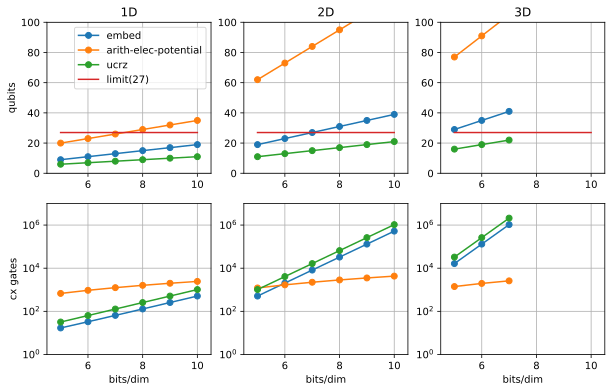

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

dirname="output/count_gates"
def csvfilename(label, dmin, dmax, nmin, nmax):
    filename=f"{dirname}/hamiltonian-gatecount-{label}-d{dmin}-{dmax}-n{nmin}-{nmax}.csv"
    return filename

def read_data(values, label, dmin, dmax, nmin, nmax):
    path = csvfilename(label,dmin,dmax,nmin,nmax)
    df = pd.read_csv(path)
    if not label in values:
        values[label] = [{},{},{}]
    for row in df.itertuples():
        series_set = values[label][row.dim-1]
        for k in ['width', 'cx']:
            if k not in series_set:
                series_set[k] = []
        values[label][row.dim-1]['width'].append(row.width)
        values[label][row.dim-1]['cx'].append(row.cx)

values={}
read_data(values, "embed", 1,3,5,7)
read_data(values, "embed", 1,2,8,10)
read_data(values, "arith-elec-potential", 1,3,5,7)
read_data(values, "arith-elec-potential", 1,2,8,10)
read_data(values, "ucrz", 1,3,5,7)
read_data(values, "ucrz", 1,2,8,10)

print(values)

LN = 27

fig, axs = plt.subplots(2,3, figsize=(10,6))
for dim in [1,2,3]:
    ax:plt.Axes = axs[0][dim-1]
    ax.grid()
    ax.set_title(f"{dim}D")
    ax.set_xlim(4.5, 10.5)
    ax.set_ylim(0, 100)
    lengthlist=[]
    for label in values.keys():
        series = values[label][dim-1]['width']
        bitcount = range(5, 5+len(series))
        lengthlist.append(5+len(series)-1)
        ax.plot(bitcount, series, label=label, marker="o")
    limy = [LN]*2
    limx = [5, 10]
    ax.plot(limx, limy, label=f"limit({LN})")
axs[0][0].legend()
axs[0][0].set_ylabel("qubits")

for dim in [1,2,3]:
    ax:plt.Axes = axs[1][dim-1]
    ax.grid()
    ax.set_xlabel("bits/dim")
    ax.set_yscale("log")
    ax.set_xlim(4.5, 10.5)
    ax.set_ylim(1, 10**7)
    for label in values.keys():
        series = values[label][dim-1]['cx']
        bitcount = range(5, 5+len(series))
        lengthlist.append(5+len(series))
        print(series)
        ax.plot(bitcount, series, label=label, marker="o")
    axs[1][0].set_ylabel("cx gates")


figfile = f"{dirname}/hamiltonian-gatecount.png"
fig.savefig(figfile)
plt.show()
